# A/B-тестирование

### Постановка задачи

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении есть датасет с действиями пользователей, техническое задание и несколько вспомогательных датасетов.

- Оцените корректность проведения теста
- Проанализируйте результаты теста

Чтобы оценить корректность проведения теста, проверьте:

- пересечение тестовой аудитории с конкурирующим тестом,
- совпадение теста и маркетинговых событий, другие проблемы временных границ теста.

### Техническое задание

- Название теста: `recommender_system_test`;
- группы: А — контрольная, B — новая платёжная воронка;
- дата запуска: 2020-12-07;
- дата остановки набора новых пользователей: 2020-12-21;
- дата остановки: 2021-01-04;
- аудитория: 15% новых пользователей из региона EU;
- назначение теста: тестирование изменений, связанных с внедрением улучшенной рекомендательной системы;
- ожидаемое количество участников теста: 6000.
- ожидаемый эффект: за 14 дней с момента регистрации пользователи покажут улучшение каждой метрики не менее, чем на 10%:
    - конверсии в просмотр карточек товаров — событие `product_page`,
    - просмотры корзины — `product_cart`,
    - покупки — `purchase`.

### Описание данных

`ab_project_marketing_events.csv` — календарь маркетинговых событий на 2020 год.

Структура файла:

- `name` — название маркетингового события;
- `regions` — регионы, в которых будет проводиться рекламная кампания;
- `start_dt` — дата начала кампании;
- `finish_dt` — дата завершения кампании.

`final_ab_new_users.csv` — пользователи, зарегистрировавшиеся с 7 по 21 декабря 2020 года.

Структура файла:

- `user_id` — идентификатор пользователя;
- `first_date` — дата регистрации;
- `region` — регион пользователя;
- `device` — устройство, с которого происходила регистрация.

`final_ab_events.csv` — действия новых пользователей в период с 7 декабря 2020 по 4 января 2021 года.

Структура файла:

- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время покупки;
- `event_name` — тип события;
- `details` — дополнительные данные о событии. Например, для покупок, `purchase,` в этом поле хранится стоимость покупки в долларах.

`final_ab_participants.csv` — таблица участников тестов.

Структура файла:

- `user_id` — идентификатор пользователя;
- `ab_test` — название теста;
- `group` — группа пользователя.

### Ход выполнения задания

- Описать цель исследования
- Исследовать данные:
    - Требуется ли преобразование типов?
    - Описать природу пропущенных значений и дубликатов, если они есть.
- Оценить корректность проведения теста. Обратить внимание на:
    - Соответствие данных требованиям технического задания. Проверить корректность всех пунктов технического задания.
    - Время проведения теста. Убедиться, что оно не совпадает с маркетинговыми и другими активностями.
    - Аудиторию теста. Удостовериться, что нет пересечений с конкурирующим тестом и нет пользователей, участвующих в двух группах теста одновременно. Проверить равномерность распределения по тестовым группам и правильность их формирования.
- Провести исследовательский анализ данных:
    - Количество событий на пользователя одинаково распределены в выборках?
    - Как число событий в выборках распределено по дням?
    - Как меняется конверсия в воронке в выборках на разных этапах?
    - Какие особенности данных нужно учесть, прежде чем приступать к A/B-тестированию?
- Оценить результаты A/B-тестирования
    - Что можно сказать про результаты A/В-тестирования?
    - Проверить статистическую разницу долей z-критерием.
- Описать выводы по этапу исследовательского анализа данных и по проведённой оценке результатов A/B-тестирования. Сделать общее заключение о корректности проведения теста.

### Цели исследования  
  
  
- Оценить корректность проведения теста
- Проанализировать результаты теста

In [1]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
from scipy import stats as st
import numpy as np
from datetime import datetime,date
import datetime as dt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.graph_objects as go
import math as mth

## Исследую данные, провожу предобработку

In [2]:
# открываю данные 
marketings = pd.read_csv('https://code.s3.yandex.net/datasets/ab_project_marketing_events.csv')
marketings.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [3]:
users = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv')
users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [4]:
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv')
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [5]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_participants.csv')
participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,482F14783456D21B,B,recommender_system_test


In [6]:
# смотрим на данные , тип и на дубликаты с пропусками
marketings.info()

print('Количество дубликатов:', marketings.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes
Количество дубликатов: 0


In [7]:
# пропуски  
marketings.isna().sum()

name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

In [8]:
# в датасете marketings отсутствуют пропуски и дубликаты. Столбцы 'start_dt' и 'finish_dt' нужно привести к типу datetime
marketings['start_dt'] = pd.to_datetime(marketings['start_dt'], format='%Y-%m-%d')
marketings['finish_dt'] = pd.to_datetime(marketings['finish_dt'], format='%Y-%m-%d')

In [9]:
users.info()

print('Количество дубликатов:', users.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     61733 non-null  object
 1   first_date  61733 non-null  object
 2   region      61733 non-null  object
 3   device      61733 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB
Количество дубликатов: 0


In [10]:
users.isna().sum()

user_id       0
first_date    0
region        0
device        0
dtype: int64

In [11]:
# в датасете users отсутствуют пропуски и дубликаты. Столбец 'first_date' нужно привести к типу datetime
users['first_date'] = pd.to_datetime(users['first_date'], format='%Y-%m-%d')

In [12]:
events.info()

print('Количество дубликатов:', events.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     440317 non-null  object 
 1   event_dt    440317 non-null  object 
 2   event_name  440317 non-null  object 
 3   details     62740 non-null   float64
dtypes: float64(1), object(3)
memory usage: 13.4+ MB
Количество дубликатов: 0


In [13]:
events.isna().mean()

user_id       0.000000
event_dt      0.000000
event_name    0.000000
details       0.857512
dtype: float64

In [14]:
# в датасете events отсутствуют дубликаты. Присутствуют пропуски в столбце 'details' - 85%. 
# Столбец 'event_dt' нужно привести к типу datetime

events['event_dt'] = pd.to_datetime(events['event_dt'])
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     440317 non-null  object        
 1   event_dt    440317 non-null  datetime64[ns]
 2   event_name  440317 non-null  object        
 3   details     62740 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 13.4+ MB


In [15]:
participants.info()
print('Количество дубликатов:', participants.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  18268 non-null  object
 1   group    18268 non-null  object
 2   ab_test  18268 non-null  object
dtypes: object(3)
memory usage: 428.3+ KB
Количество дубликатов: 0


In [16]:
participants.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [17]:
# в датасете participants отсутствуют пропуски и дубликаты. Типы данных соответсвуют.

<AxesSubplot:>

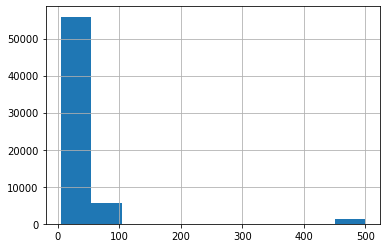

In [18]:
# посмотрим на пропуски поподробнее
events['details'].hist()

In [19]:
events['details'].describe()

count    62740.000000
mean        23.877631
std         72.180465
min          4.990000
25%          4.990000
50%          4.990000
75%          9.990000
max        499.990000
Name: details, dtype: float64

In [20]:
events_isna = events[events['details'].isna()]
events_isna.head(5)

,user_id,event_dt,event_name,details
62740,2E1BF1D4C37EA01F,2020-12-07 09:05:47,product_cart,NaN
62741,50734A22C0C63768,2020-12-07 13:24:03,product_cart,NaN
62742,5EB159DA9DC94DBA,2020-12-07 22:54:02,product_cart,NaN
62743,084A22B980BA8169,2020-12-07 15:25:55,product_cart,NaN
62744,0FC21E6F8FAA8DEC,2020-12-07 06:56:27,product_cart,NaN


In [21]:
# добавим столбец 'details_NaN'
events['details_Nan'] = np.where(events['details'].isnull(), 0,1)
events.head()

,user_id,event_dt,event_name,details,details_Nan
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99,1
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99,1
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99,1
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,1
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99,1


In [22]:
events.groupby(['details_Nan']) ['event_name'].value_counts(normalize=True)

details_Nan  event_name  
0            login           0.502022
             product_page    0.332549
             product_cart    0.165429
1            purchase        1.000000
Name: event_name, dtype: float64

Возможно пропуски связаны с ошибкой выгрузки. Либо если посмотреть на группировку много пропусков именно в наименованиях события login, product_page, product_cart - и можно предположить, что цены просто не были занесены по этим событиям. В любом случае, пока я оставлю эти пропуски, чтобы не тратить на это время, т.к. столбец 'details'- по описанию данных является дополнительной информацией и на исследование не влияет.

##### Провели загрузку и просмотр данных, проверили их на дубликаты и подтвердили отсутствие. Скорректировали тип данных в столбцах 'start_dt' и 'finish_dt' датасета marketings, в 'first_date' датасета users, в 'event_dt' датасета events на тип datetime.  
##### Также нашли пропуски в столбце 'details' датасета events. Решили пока не трогать по причине того, что информация в столбце является дополнительной и не окажет влияние на исследование.

## Проверяю на корректность проведения теста

In [23]:
# для удобства проверки объединяю в один датасет три датасета 
total_data = participants.merge(users, on='user_id')
total_data = total_data.merge(events, on='user_id', how='left')
total_data = total_data.drop(columns='details_Nan', axis=1)

# проверяем наименование теста
display('наименование тестов:')
display(total_data['ab_test'].value_counts())

# проверяем название групп
display('наимнование групп:')
display(total_data['group'].value_counts())

# теперь проверяем даты запуска: 2020-12-07
# даты остановки набора новых пользователей: 2020-12-21
# датs остановки: 2021-01-04
# сначала возьмем только участников нашего теста
rst = total_data[total_data['ab_test'] == 'recommender_system_test']
# display(rst.head())
print(f'Дата запуска теста: {rst["first_date"].min()}')
print(f'Дата остаковки набора пользователей на тест: {rst["first_date"].max()}')
print(f'Дата остановки теста: {rst["event_dt"].max()}')
print()

# смотрю на долю аудитории и количество участников теста
reg_data = rst['first_date'].min()
region_user = rst[rst['event_dt'] >= reg_data]
# display(region_user.head())
region_user = rst.groupby('region')['user_id'].nunique().reset_index()
# display(region_user.head())
print('Количество участников теста:', region_user['user_id'].sum())
print()
mean_eu = users.groupby('region')['user_id'].nunique().reset_index()
#display(mean_eu)
print('Доля новых пользователей из региона EU:', round((region_user.loc[2, 'user_id'] / mean_eu.loc[2, 'user_id'] * 100), 2))

'наименование тестов:'

interface_eu_test          82644
recommender_system_test    27724
Name: ab_test, dtype: int64

'наимнование групп:'

A    62315
B    48053
Name: group, dtype: int64

Дата запуска теста: 2020-12-07 00:00:00
Дата остаковки набора пользователей на тест: 2020-12-21 00:00:00
Дата остановки теста: 2020-12-30 12:42:57

Количество участников теста: 6701

Доля новых пользователей из региона EU: 13.73


##### Краткий вывод:  
Был проведен краткий анализ данных на соответствие ТЗ. При этом анализе было выявлено следующее:  
- наименование теста "recommender_system_test" соответствует ТЗ,  
- присутствие двух групп А и В соответствуют ТЗ,  
- дата запуска теста: 2020-12-07 00:00:00 соответствует ТЗ,  
- дата остаковки набора пользователей на тест: 2020-12-21 00:00:00 не соответствует ТЗ, набор был остановлен на 2 недели раньше,  
- дата остановки теста: 2020-12-30 12:42:57 не соответствует ТЗ, тест был остановлен на 5 дней раньше,    
- доля новых пользователей из региона EU равна 13,73%, что не соответствует ТЗ (требуется 15%),  
- количество участников теста составило 6701 , что не соответствует ТЗ (требуется 6000).

##### Посмотрим на время теста и проверим не совпадает ли оно с другими маркетинговыми мероприятиями

In [24]:
rst.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27724 entries, 0 to 34332
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     27724 non-null  object        
 1   group       27724 non-null  object        
 2   ab_test     27724 non-null  object        
 3   first_date  27724 non-null  datetime64[ns]
 4   region      27724 non-null  object        
 5   device      27724 non-null  object        
 6   event_dt    24698 non-null  datetime64[ns]
 7   event_name  24698 non-null  object        
 8   details     3331 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 2.1+ MB


In [25]:
marketings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 576.0+ bytes


In [26]:
start_event = rst['event_dt'].min() 
finish_event = rst['event_dt'].max()  

display(marketings[(marketings['start_dt'] >= start_event) & (marketings['finish_dt'] >= finish_event)])

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


In [27]:
market_query = marketings[marketings['finish_dt'] <= datetime(2021, 1, 7)].sort_values(by='finish_dt', ascending=False)
market_query

,name,regions,start_dt,finish_dt
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
12,Single's Day Gift Promo,APAC,2020-11-11,2020-11-12
13,Chinese Moon Festival,APAC,2020-10-01,2020-10-07
4,4th of July Promo,N.America,2020-07-04,2020-07-11
11,Dragon Boat Festival Giveaway,APAC,2020-06-25,2020-07-01
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19


- В периоды с 25 декабря 2020 по 3 января 2021 в регионах EU и N.America проходит Рождество и Новый год,  
- С 30 декабря 2020 по 7 января 2021 в CIS проходит новогодняя лотерея.  
- Также во всех вышеуказанных регионах (EU, CIS, APAC, N.America) в период с 26 ноября 2020 по 1 декабря 2020 проходила черная пятница (распродажи).  
Учитывая то, что у нас тест проходит согласно ТЗ с 7 декабря 2020 по 4 января 2021 (а фактически тест остановлен 30 декабря 2020) и маркетинговая компания могла начальться и до 7 декабря 2020, то распродажи в черной пятнице точно повлияли на результаты теста.

In [28]:
marketings.query('finish_dt >= "2020-12-07" and start_dt <="2021-01-04"')

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


##### Смотрю на возможность пересечений с другим тестом и на пользователей возможно участвующих в двух тестах одновременно

In [29]:
# смотрим информацию по другому тесту : 
iet = total_data[total_data['ab_test'] == 'interface_eu_test']
display(iet.head())
print(f'Дата запуска теста: {iet["first_date"].min()}')
print(f'Дата остаковки набора пользователей на тест: {iet["first_date"].max()}')
print(f'Дата остановки теста: {iet["event_dt"].max()}')

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details
17,DABC14FDDFADD29E,A,interface_eu_test,2020-12-08,EU,Mac,2020-12-08 11:30:58,login,NaN
18,DABC14FDDFADD29E,A,interface_eu_test,2020-12-08,EU,Mac,2020-12-11 12:52:32,login,NaN
19,DABC14FDDFADD29E,A,interface_eu_test,2020-12-08,EU,Mac,2020-12-18 11:10:45,login,NaN
35,04988C5DF189632E,A,interface_eu_test,2020-12-14,EU,iPhone,2020-12-14 18:51:34,purchase,4.99
36,04988C5DF189632E,A,interface_eu_test,2020-12-14,EU,iPhone,2020-12-15 02:39:20,purchase,4.99


Дата запуска теста: 2020-12-07 00:00:00
Дата остаковки набора пользователей на тест: 2020-12-23 00:00:00
Дата остановки теста: 2020-12-30 18:28:55


In [30]:
users_group = total_data.groupby('user_id').nunique().reset_index()  
users_group

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details
0,0002CE61FF2C4011,1,1,1,1,1,10,3,0
1,000ABE35EE11412F,1,1,1,1,1,0,0,0
2,001064FEAAB631A1,1,2,1,1,1,6,2,0
3,0010A1C096941592,1,1,1,1,1,7,3,2
4,001C05E87D336C59,1,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...
16661,FFE858A7845F005E,1,1,1,1,1,0,0,0
16662,FFED90241D04503F,1,2,1,1,1,0,0,0
16663,FFEFC0E55C1CCD4F,1,1,1,1,1,4,1,0
16664,FFF28D02B1EACBE1,2,2,1,1,1,6,3,0


In [31]:
# считаю количество пользователей, которые участвовали в двух тестах
count = 0
for user in users_group['ab_test']:
    if user > 1:
        count += 1
print(count)

1602


In [32]:
# считаю долю пересечения

mean_user = round((count / users_group['user_id'].count() *100), 2)
mean_user

9.61

##### Краткий вывод: 
Тест под названием "interface_eu_test" проводился одновременно с нашим тестом ("recommender_system_test") в период с 7 декабря 2020 по 30 декабря 2020. Соответственно логично, что мы выявили пересечение в количестве 1602 пользователей, которые участвовали в двух тестах одновременно. Доля от общего количества пользователей составляет 9,61 % , что тоже может повлиять на результат теста. Но с другой стороны процент не высок , а также они являются участниками нашего теста тоже, поэтому 

Но с другой стороны процент не высок , а так как они являются участниками нашего теста тоже, удаление может повлиять также на результат. Решено оставить. 

##### Теперь смотрим на равномерность распределения пользователей и правильность формирования

In [33]:
# делаю тоже самое, что и выше по пересечению
rst_user_group = rst.groupby('user_id').nunique().reset_index()
display(rst_user_group)

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details
0,000ABE35EE11412F,1,1,1,1,1,0,0,0
1,001064FEAAB631A1,1,1,1,1,1,6,2,0
2,0010A1C096941592,1,1,1,1,1,7,3,2
3,001C05E87D336C59,1,1,1,1,1,0,0,0
4,00341D8401F0F665,1,1,1,1,1,2,1,0
...,...,...,...,...,...,...,...,...,...
6696,FFC2C5F898D1245B,1,1,1,1,1,0,0,0
6697,FFC53FD45DDA5EE8,1,1,1,1,1,0,0,0
6698,FFE858A7845F005E,1,1,1,1,1,0,0,0
6699,FFED90241D04503F,1,1,1,1,1,0,0,0


In [34]:
count_rst = 0
for user in rst_user_group['group']:
    if user > 1:
        count_rst += 1
print(count_rst)

0


In [35]:
# доля участников по отношению к тесту "recommender_system_test"
mean_user_rst = round((count / rst_user_group['user_id'].count() *100), 2)
mean_user_rst

23.91

In [36]:
rst.groupby('group')['user_id'].nunique()

group
A    3824
B    2877
Name: user_id, dtype: int64

##### Краткий вывод: 
Участники между группами не пересекаются, в каждой группе уникальные. Но пересечение по двум тестам уже выше, почти  24% участников от общего количества участников теста "recommender_system_test" участвовали в другом тесте ("interface_eu_test"). Также группы распределены не равномерно. В контрольной группе "А" теста - 3824 пользователя, в группе "В" - 2877 пользователя. 

## Исследовательский анализ данных

##### Проверяем как распределено количество событий на пользователя в выборках

In [37]:
# смотрю группу А
group_A = rst[rst['group'] == 'A']
#display(group_A)
events_users_A = group_A.groupby('event_name')['user_id'].nunique().sort_values(ascending = False).reset_index()
#смотрю долю пользователей в каждом событии:
events_users_A['mean'] = round((events_users_A['user_id'] / rst['user_id'].nunique()), 2)
display(events_users_A)

,event_name,user_id,mean
0,login,2747,0.41
1,product_page,1780,0.27
2,purchase,872,0.13
3,product_cart,824,0.12


In [38]:
# смотрю группу B
group_B = rst[rst['group'] == 'B']
#display(group_B)
events_users_B = group_B.groupby('event_name')['user_id'].nunique().sort_values(ascending = False).reset_index()
#смотрю долю пользователей в каждом событии:
events_users_B['mean'] = round((events_users_B['user_id'] / rst['user_id'].nunique()),2)
display(events_users_B)

,event_name,user_id,mean
0,login,928,0.14
1,product_page,523,0.08
2,purchase,256,0.04
3,product_cart,255,0.04


Интересное наблюдение. По факту видно, что распределение количества событий на пользователя не равномерное, группа В сильно меньше, но я думаю это логично учитывая, что выше мы выявили не равное распеределение между участниками групп теста.  
Еще можно отметить, что доля в группе В сильно снизилась по сравнению с контрольной группой. Мы помним, что есть условие про ожидаемый эффект: за 14 дней с момента регистрации пользователи покажут улучшение каждой метрики не менее, чем на 10%. Здесь точно нет этого увеличения, давайте сделаем срез по 14 дням и убедимся в этом.

In [39]:
# делаю срез по дате
rst_query = rst[rst['event_dt'] <= '2020-12-21']
# смотрю группу А
group_A_query = rst_query[rst_query['group'] == 'A']
#display(group_A)
events_users_A_query = group_A_query.groupby('event_name')['user_id'].nunique().sort_values(ascending = False).reset_index()
#смотрю долю пользователей в каждом событии:
events_users_A_query['mean'] = round((events_users_A_query['user_id'] / rst_query['user_id'].nunique()), 2)
display(events_users_A_query)

,event_name,user_id,mean
0,login,2330,0.74
1,product_page,1504,0.48
2,purchase,734,0.23
3,product_cart,704,0.22


In [40]:
# смотрю группу B
group_B_query = rst_query[rst_query['group'] == 'B']
#display(group_B)
events_users_B_query = group_B_query.groupby('event_name')['user_id'].nunique().sort_values(ascending = False).reset_index()
#смотрю долю пользователей в каждом событии:
events_users_B_query['mean'] = round((events_users_B_query['user_id'] / rst_query['user_id'].nunique()),2)
display(events_users_B_query)

,event_name,user_id,mean
0,login,834,0.26
1,product_page,472,0.15
2,product_cart,234,0.07
3,purchase,230,0.07


Что и следовало ожидать из выше сделанной проверки, за 14 дней не произошло улучшение каждой метрики на 10%, как мы видим произошло даже ухудшение. 

##### Cмотрим распределение числа событий по дням

In [41]:
# сначала подготовлю датафреймы необходимые для построения распределений, сделаю срезы
rst['event_dt'] = pd.to_datetime(rst['event_dt']).dt.date
# первое login:
login = rst[rst['event_name'] == 'login']
#display(login.head())
login_A = login[login['group'] == 'A']
#display(login_A)
login_B = login[login['group'] == 'B']
#display(login_B)

/tmp/ipykernel_85/296011316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rst['event_dt'] = pd.to_datetime(rst['event_dt']).dt.date


In [42]:
# второе product_page:
product_page = rst[rst['event_name'] == 'product_page']
#display(product_page.head())
product_page_A = product_page[product_page['group'] == 'A']
product_page_B = product_page[product_page['group'] == 'B']
#display(product_page_A)
#display(product_page_B)

In [43]:
# третье product_cart:
product_cart = rst[rst['event_name'] == 'product_cart']
#display(product_cart.head())
product_cart_A = product_cart[product_cart['group'] == 'A']
product_cart_B = product_cart[product_cart['group'] == 'B']
#display(product_cart_A)
#display(product_cart_B)

In [44]:
# последнее purchase:
purchase = rst[rst['event_name'] == 'purchase']
#display(purchase.head())
purchase_A = purchase[purchase['group'] == 'A']
purchase_B = purchase[purchase['group'] == 'B']
#display(purchase_A)
#display(purchase_B)

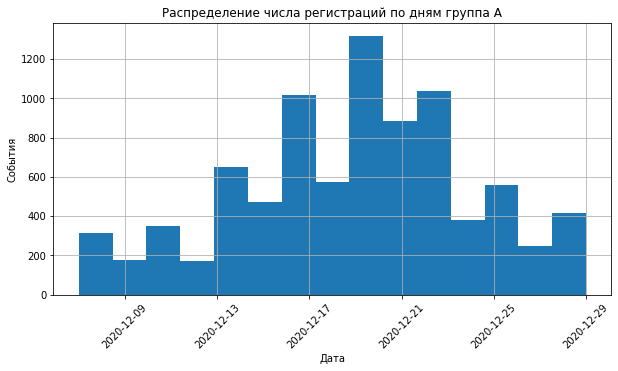

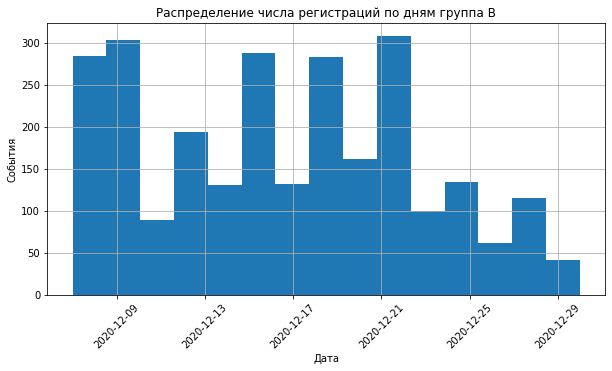

In [45]:
# теперь смотрим на распределение регистраций
listt = [login_A['event_dt'], login_B['event_dt']]
names = ['Распределение числа регистраций по дням группа A', 
         'Распределение числа регистраций по дням группа B']
for element, name in zip(listt, names):
    plt.figure(figsize=(10, 5))
    ax = element.hist(bins=15)
    plt.xlabel('Дата')
    plt.ylabel('События')
    plt.xticks(rotation=45)
    ax.set_title(name)
    plt.show()

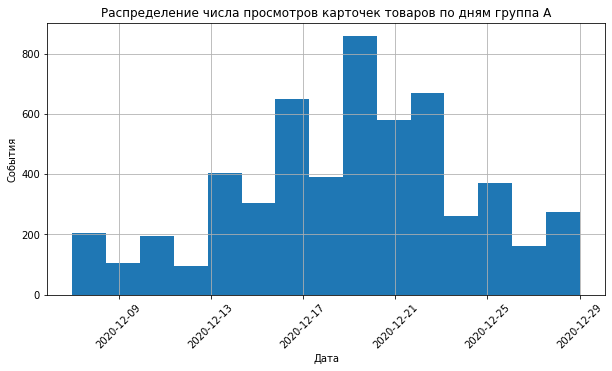

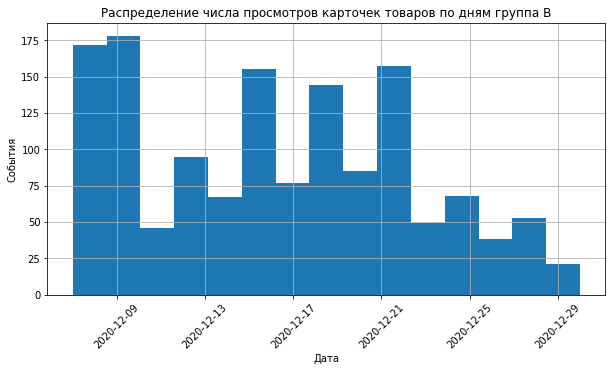

In [46]:
# теперь смотрим на распределение просмотра карточки товаров 
listt = [product_page_A['event_dt'], product_page_B['event_dt']]
names = ['Распределение числа просмотров карточек товаров по дням группа А', 
         'Распределение числа просмотров карточек товаров по дням группа B']
for element, name in zip(listt, names):
    plt.figure(figsize=(10, 5))
    ax = element.hist(bins=15)
    plt.xlabel('Дата')
    plt.ylabel('События')
    plt.xticks(rotation=45)
    ax.set_title(name)
    plt.show()

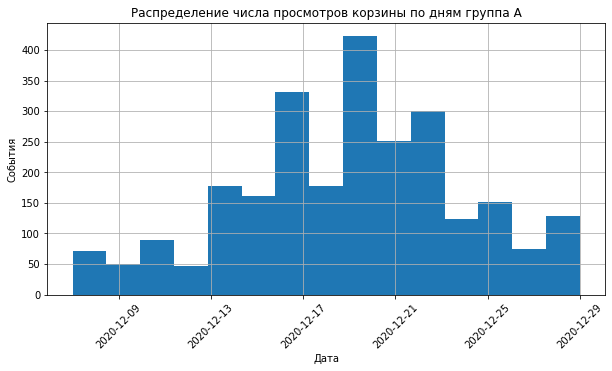

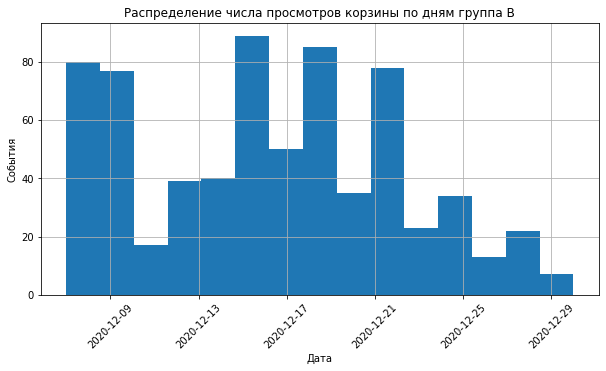

In [47]:
# теперь смотрим на распределение просмотра корзины 
listt = [product_cart_A['event_dt'], product_cart_B['event_dt']]
names = ['Распределение числа просмотров корзины по дням группа А', 
         'Распределение числа просмотров корзины по дням группа B']
for element, name in zip(listt, names):
    plt.figure(figsize=(10, 5))
    ax = element.hist(bins=15)
    plt.xlabel('Дата')
    plt.ylabel('События')
    plt.xticks(rotation=45)
    ax.set_title(name)
    plt.show()

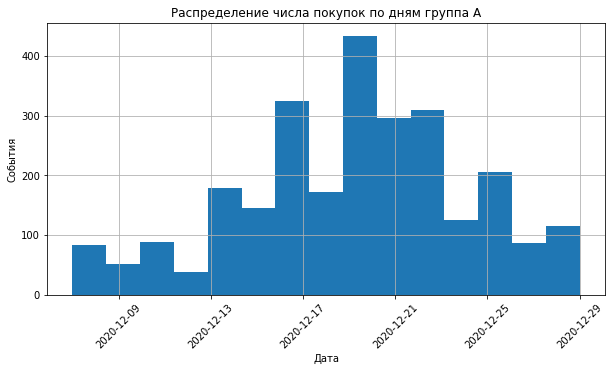

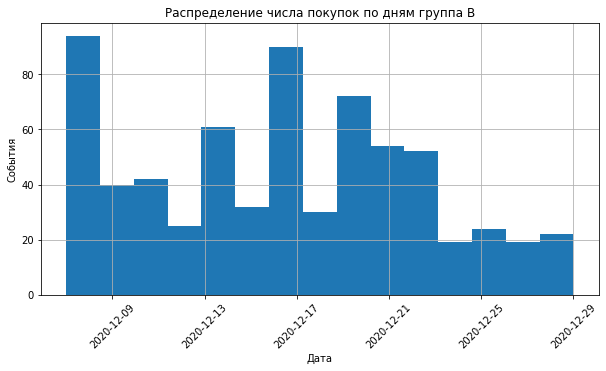

In [48]:
# теперь смотрим на распределение покупок 
listt = [purchase_A['event_dt'], purchase_B['event_dt']]
names = ['Распределение числа покупок по дням группа А', 
         'Распределение числа покупок по дням группа B']
for element, name in zip(listt, names):
    plt.figure(figsize=(10, 5))
    ax = element.hist(bins=15)
    plt.xlabel('Дата')
    plt.ylabel('События')
    plt.xticks(rotation=45)
    ax.set_title(name)
    plt.show()

##### Краткий вывод:  
Распределение данных между событиями коррелируют, различаются только между группами и количеством:  
- Так при регистрации своего пика достигают (более 1200) на 19 декабря группа А, между тем группа В уже с 9 декабря активно начинает регистрироваться (более 300). И на спад группа А начинает с 21 декабря и до конца уже. Группа В наоборот еще волнообразно доходит до пика 14,18,21 декабря и также после 21 числа снижается.  
- Просмотры карточек товаров также в группе А достигают своего пика 19 декабря (более 800), у группы В вслед а регистрацией 9 декабря более 175 просмотров карточек товаров. На спад просмотры идут у обоих групп с 21 декабря.  
- Просмотр корзины более 400(450) группа А набирает 19 декабря и дальше идет на снижение. Группа В несколько дней достигает своего пика 14 , 18 декабря (более 80), потом снижается и последний раз "взрывается" 21 декабря дойдя почти до 80.  
- Покупки группа А совершает на пике 19 декабря (более 400) и идет на спад с 21 декабря. Группа В максимальное число покупок (более 80) совершает в первые дни (8 декабря более 80), далее 16 декабря происходит еще всплеск и до конца идет снижение.  

Посмотрев на распределение для полноты понимания необходимо точно построить воронку.

##### Смотрим как меняется конверсия в воронке в выборках на разных этапах

In [49]:
# посчитаем события по наименованию и отсортируем
rst['event_name'].value_counts()

login           11190
product_page     6930
purchase         3331
product_cart     3247
Name: event_name, dtype: int64

In [50]:
# считаем количество пользователей совершивших хотя бы одно событие и их долю
user_events = (rst.groupby('event_name').agg({'event_name' : 'count', 'user_id' : 'nunique'})
                                         .sort_values(by = 'user_id', ascending=False))
user_events['share_%'] = round((user_events['user_id'] / rst['user_id'].nunique() * 100), 2)
user_events.columns = ['event_count', 'user_id', 'share_%']
user_events = user_events.reset_index()
user_events = user_events.reindex(index=[0,1,3,2])
user_events

,event_name,event_count,user_id,share_%
0,login,11190,3675,54.84
1,product_page,6930,2303,34.37
3,product_cart,3247,1079,16.10
2,purchase,3331,1128,16.83


Первоначально я переведу события:  
login - регистрация  
product_page - просмотр карточек товаров  
purchase - покупка  
product_cart - просмотры корзины  

Воронка в целом так и выстраивается: сначала пользователь регистрируется (login), далее выбирает товар (product_page) и после покупает (purchase). Выпадает только шаг с корзиной (потому что обычно пользователь должен добавить в корзину, после купить). Но если посмотреть на количество действий разница между покупками (3331) и корзиной (3247) не значительна, есть всегда вероятность просмотреть товар и купить его оффлайн или по телефону. Поэтому строим воронку , меня не смущает изменение расположений двух последних шагов.

In [51]:
# посчитаем конверсию каждого шага в воронке
user_events['conversion'] = 0
for i in range(0, len(user_events['share_%'])):
    if i == 0:
        user_events['conversion'].iloc[i] = 100
    else:
        user_events['conversion'].iloc[i] = round(int(user_events['user_id'].iloc[i])
                                                  / int(user_events['user_id'].iloc[i-1]), 2)*100
user_events

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


,event_name,event_count,user_id,share_%,conversion
0,login,11190,3675,54.84,100
1,product_page,6930,2303,34.37,63
3,product_cart,3247,1079,16.10,47
2,purchase,3331,1128,16.83,105


In [52]:
# еще на основе таблицы построим визуализацию: 
fig = go.Figure(go.Funnel(x = user_events['conversion'],
                          y = user_events['event_name'],
                          textinfo = 'percent initial',
                          hoverinfo = 'percent initial'))
fig.update_layout(title='Воронка событий с конверсией каждого шага')
fig.show();

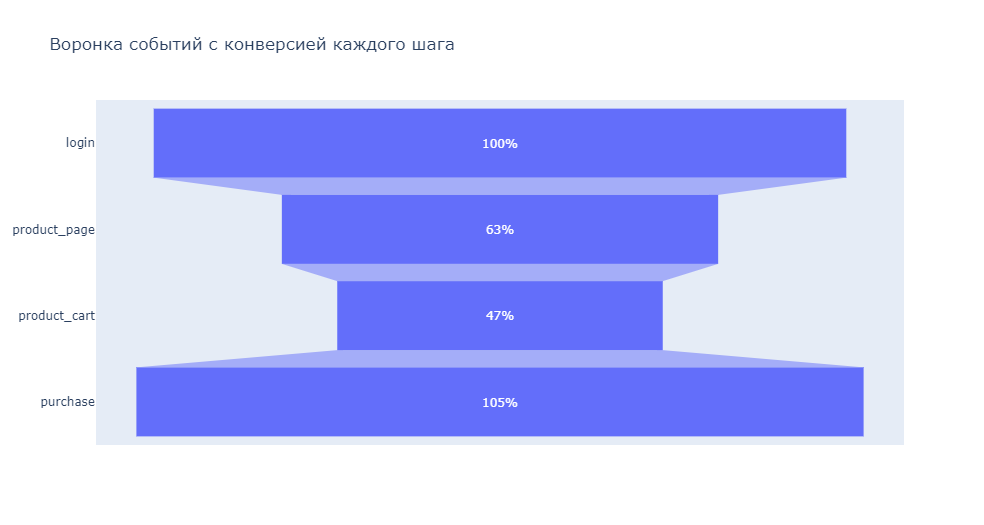

In [53]:
# и построим такую же воронку для наглядности по конверсии с первого шага до оплаты
fig = go.Figure(go.Funnel(x = user_events['share_%'], 
                          y = user_events['event_name'],
                          hoverinfo = 'x'))
                          
fig.update_layout(title='Воронка событий с показателем конверсии от начального шага')
fig.show();

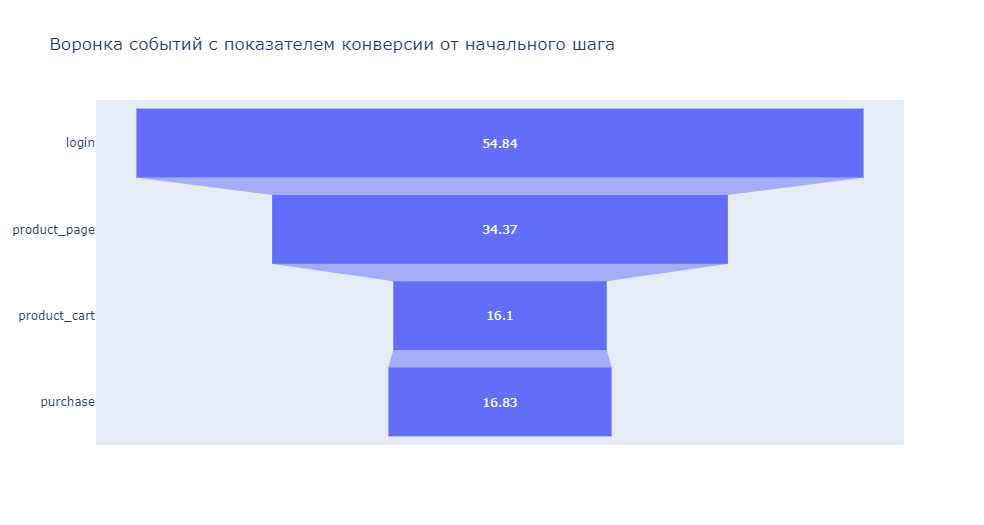

##### Краткий вывод:  
Мы расчитали конверсию с этапа когда пользователи регистрируются и до оплаты (включая просмотр корзины), а также отношения последующего этапа к предыдущему. Построили визуализацию по воронкам событий. Что мы увидели :  

Если рассмотреть событийную воронку от этапа регистрации и до покупки, то мы видим, что 47% пользователей дошли до корзины и из них все точно купили плюс еще добавились те, кто миновал корзину и приобрел сразу. Поэтому этам покупки у нас отображен 105%. До этапа просмотра товара доходят 63% от зарегистрированных, а 37% уже куда-то уходят. 
По итогу из всех зарегистрирвованных совершили событие 3675 пользователей, посмотрели товар 2303 человека, купили 1128 человек. Шаг с корзиной (в которую люди положили меньше товаров чем купили) можно обьяснить возможно приобретением или оффлайн (приходом в магазин) или же заказом по телефону. Также если есть возможность прямого оформления, минуя корзину это тоже могло бы обьснить такую разницу. Также посмотреть можно настройки сайта. В корзину добавили 1079 пользователей. Разница не существена.  
Таким образом я бы дал рекомендации разработчикам проверить сайт на этапе оформления покупки и добавления в корзину, а отделу маркетинга стоит на этапе после регистрации пользователя поработать над каким-либо предложением или всплывающим окном для увеличения заинтересованности пользователя и перехода его в следующий этап.

##### Какие еще могут быть особенности данных

In [54]:
rst.head()

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07,purchase,99.99
1,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-25,purchase,4.99
2,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07,product_cart,NaN
3,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-25,product_cart,NaN
4,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07,product_page,NaN


In [55]:
# мы в течении всего исследования не касались столбцов device и details. В столбце details у нас обнаружены пропуски  
# и было принято решение не трогать их и сэкономить время по причине того, что в исследовании данные использоваться не будут.  
# столбец device был не проанализирован вообще и можно посмотреть на него
rst['device'].value_counts()

Android    12143
PC          7089
iPhone      5827
Mac         2665
Name: device, dtype: int64

Участники используют 4 разных девайся для просмотра сайта и приобретения товаров. Здесь больше техническая сторона вопроса, но стоит учесть этот момент. Точно будет по разному виден сайт и путь клиента у кого iPhone и тот кто заходит с PC, или Android. На тест это тоже может повлиять. 

#### По результатам A/B-теста  
С самого начала выявлено не соответствие данных с ТЗ.  
- дата остаковки набора пользователей на тест: 2020-12-21 00:00:00 не соответствует ТЗ, набор был остановлен на 2 недели раньше,
- дата остановки теста: 2020-12-30 12:42:57 не соответствует ТЗ, тест был остановлен на 5 дней раньше,  
- доля новых пользователей из региона EU равна 13,73%, что не соответствует ТЗ (требуется 15%),  
- количество участников теста составило 6701 , что не соответствует ТЗ (требуется 6000),
Тем не менее было и соответствие ТЗ:  
- наименование теста "recommender_system_test" соответствует ТЗ,
- присутствие двух групп А и В соответствуют ТЗ,
- дата запуска теста: 2020-12-07 00:00:00 соответствует ТЗ. 

В части проведения самого теста было выявлено пересечение с другим тестом в количестве 1602 пользователей, которые участвовали в двух тестах одновременно. Доля от общего количества пользователей составляет 9,61 % , что тоже может повлиять на результат теста. Также тест проводился одновременно с двумя другими крупными маркетинговыми мероприятиями - в периоды с 25 декабря 2020 по 3 января 2021 в регионах EU и N.America проходит Рождество и Новый год, а с 30 декабря 2020 по 7 января 2021 в CIS проходит новогодняя лотерея. Дополнительно во всех вышеуказанных регионах (EU, CIS, APAC, N.America) в период с 26 ноября 2020 по 1 декабря 2020 проходила черная пятница (распродажи). Что тоже оказывает влияние на тест.  
Участники между группами не пересекаются, в каждой группе уникальные. Но пересечение по двум тестам уже выше, почти 24% участников от общего количества участников теста "recommender_system_test" участвовали в другом тесте ("interface_eu_test"). Также группы распределены не равномерно. В контрольной группе "А" теста - 3824 пользователя, в группе "В" - 2877 пользователя. Неравномерность распределения по группам теста и пересечение с другим проводимым тестом также могут оказывать влияние на результат.  
В дополнении к этому за 14 дней не произошло улучшение каждой метрики на 10%, а наоборот произошло ухудшение. Что тоже не в пользу проведенного теста. 

##### Проводим статистическую разницу долей z-критерием

In [56]:
rst.head()

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07,purchase,99.99
1,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-25,purchase,4.99
2,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07,product_cart,NaN
3,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-25,product_cart,NaN
4,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07,product_page,NaN


In [57]:
# посмотрим сколько пользователей в группах: 
users_group = rst.groupby('group')['user_id'].nunique()
users_group['AB'] = users_group['A'] + users_group['B']
users_group

group
A     3824
B     2877
AB    6701
Name: user_id, dtype: int64

In [58]:
# перед тем как провести тест , создам сводную таблицу расчитаю самое популярное событие и доли пользователей
test_group = rst.pivot_table(index='event_name',
                             columns='group',
                             values='user_id',
                             aggfunc='nunique').reset_index().sort_values(by='A', ascending=False)
test_group['AB'] = test_group['A'] + test_group['B']
test_group

group,event_name,A,B,AB
0,login,2747,928,3675
2,product_page,1780,523,2303
3,purchase,872,256,1128
1,product_cart,824,255,1079


In [59]:
# теперь напишем функцию для проведения z-test : 
def z_test(group1, group2, alpha):
    for i in test_group.index:
        p1 = test_group[group1][i] / users_group[group1]
        p2 = test_group[group2][i] / users_group[group2]
        p_combined = ((test_group[group1][i] + test_group[group2][i]) / 
                 (users_group[group1] + users_group[group2]))
        
        difference = p1 - p2
        
        z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * 
                                        (1/users_group[group1] + 1/users_group[group2]))
        
        distr = st.norm(0, 1) 
        p_value = (1 - distr.cdf(abs(z_value))) * 2
        
        print('{} p-значение: {}'.format(test_group['event_name'][i], p_value))
        if (p_value < alpha):
            print("Нулевую гипотезу нужно отвергнуть: различия между долями статистически значимы")
        else:
            print("Нулевую гипотезу не получилось отвергнуть, статистически значимой разницы между долями нет")
        print('')

###### Прежде чем провести первые тесты, сформулируем гипотезы:  
###### Н0: Статистической значимой разницы между долями нет
###### Н1: Различия между долями статистически значимы 

In [60]:
# используем поправку Бонферрони
alpha = 0.05 / 4
alpha

0.0125

In [61]:
# Теперь проводим А/В тест (А/B группы)
z_test('A','B', 0.0125)

login p-значение: 0.0
Нулевую гипотезу нужно отвергнуть: различия между долями статистически значимы

product_page p-значение: 0.0
Нулевую гипотезу нужно отвергнуть: различия между долями статистически значимы

purchase p-значение: 0.0
Нулевую гипотезу нужно отвергнуть: различия между долями статистически значимы

product_cart p-значение: 0.0
Нулевую гипотезу нужно отвергнуть: различия между долями статистически значимы



##### Краткий вывод: 
По всем нашим событиям (регистрация, просмотр товара, покупка и просмотр корзины) по результатам проведения АВ теста необходимо отвергнуть нулевую гипотезу - разница между долями статистически значима.

## Вывод: 
Тест под названием "recommender_system_test" проведен не корреткно. 

**Cоответствие ТЗ**
По результатам проверки данных на соответствие к ТЗ были выявлены следующие проблемы:  
- дата остаковки набора пользователей на тест: 2020-12-21 00:00:00 не соответствует ТЗ, набор был остановлен на 2 недели раньше,  - дата остановки теста: 2020-12-30 12:42:57 не соответствует ТЗ, тест был остановлен на 5 дней раньше,  
- доля новых пользователей из региона EU равна 13,73%, что не соответствует ТЗ (требуется 15%),  
- количество участников теста составило 6701 , что не соответствует ТЗ (требуется 6000),  
Следующие параметры соответствовали ТЗ:  
- наименование теста "recommender_system_test" соответствует ТЗ,  
- присутствие двух групп А и В соответствуют ТЗ,  
- дата запуска теста: 2020-12-07 00:00:00 соответствует ТЗ.  

**По итогу проведения исследовательского анализа данных было выявлено:**  
- В части проведения самого теста было выявлено пересечение с другим тестом в количестве 1602 пользователей, которые участвовали в двух тестах одновременно. Доля от общего количества пользователей составляет 9,61 % , что тоже может повлиять на результат теста. Было решено не удалять пользователя, т.к. они являются такими же участниками нашего теста.  
- Также тест проводился одновременно с двумя другими крупными маркетинговыми мероприятиями - в периоды с 25 декабря 2020 по 3 января 2021 в регионах EU и N.America проходит Рождество и Новый год, а с 30 декабря 2020 по 7 января 2021 в CIS проходит новогодняя лотерея. Дополнительно во всех вышеуказанных регионах (EU, CIS, APAC, N.America) в период с 26 ноября 2020 по 1 декабря 2020 проходила черная пятница (распродажи). Что тоже оказывает влияние на тест.  
- Участники между группами не пересекаются, в каждой группе уникальные. Но пересечение по двум тестам уже выше, почти 24% участников от общего количества участников теста "recommender_system_test" участвовали в другом тесте ("interface_eu_test"). Также группы распределены не равномерно. В контрольной группе "А" теста - 3824 пользователя, в группе "В" - 2877 пользователя. Неравномерность распределения по группам теста и пересечение с другим проводимым тестом также могут оказывать влияние на результат.  
- В части распределения количества событий на пользователя - оно не равномерно, группа В сильно меньше.


Важно отметить, что доля в группе В сильно снизилась по сравнению с контрольной группой, за 14 дней не произошло улучшение каждой метрики на 10%, а наоборот произошло ухудшение. Что тоже не в пользу проведенного теста.

Распределение данных между событиями коррелируют, различаются только между группами и количеством:
- Так при регистрации своего пика достигают (более 1200) на 19 декабря группа А, между тем группа В уже с 9 декабря активно начинает регистрироваться (более 300). И на спад группа А начинает с 21 декабря и до конца уже. Группа В наоборот еще волнообразно доходит до пика 14,18,21 декабря и также после 21 числа снижается.
- Просмотры карточек товаров также в группе А достигают своего пика 19 декабря (более 800), у группы В вслед а регистрацией 9 декабря более 175 просмотров карточек товаров. На спад просмотры идут у обоих групп с 21 декабря.
- Просмотр корзины более 400(450) группа А набирает 19 декабря и дальше идет на снижение. Группа В несколько дней достигает своего пика 14 , 18 декабря (более 80), потом снижается и последний раз "взрывается" 21 декабря дойдя почти до 80.
- Покупки группа А совершает на пике 19 декабря (более 400) и идет на спад с 21 декабря. Группа В максимальное число покупок (более 80) совершает в первые дни (8 декабря более 80), далее 16 декабря происходит еще всплеск и до конца идет снижение.


**В части воронки** - если рассмотреть событийную воронку от этапа регистрации и до покупки, то мы видим, что 47% пользователей дошли до корзины и из них все точно купили плюс еще добавились те, кто миновал корзину и приобрел сразу. Поэтому этам покупки у нас отображен 105%. До этапа просмотра товара доходят 63% от зарегистрированных, а 37% уже куда-то уходят.  
По итогу из всех зарегистрированных совершили событие 3675 пользователей, посмотрели товар 2303 человека, купили 1128 человек. Шаг с корзиной (в которую люди положили меньше товаров чем купили) можно обьяснить не строгостью воронки.  

**Дополнительно** участники используют 4 разных девайся для просмотра сайта и приобретения товаров. Здесь больше техническая сторона вопроса, но стоит учесть этот момент. Точно будет по разному виден сайт и путь клиента у кого iPhone и тот кто заходит с PC, или Android. На тест это тоже может повлиять.  

**Переходим к А/В тесту и проведению анализа его результата.**
Во первых была проведена проверка выборок, которая показала что количество пользователей различно между выборками.  

**Далее сформулировав гипотезы :**  
Н0: Статистической значимой разницы между долями нет  
Н1: Различия между долями статистически значимы  
Был проведен А/В тест с 4 проверками статистических гипотез:  
А/В - 4 проверки (по каждому событию)

**Который показал абсолютно во всех тестах один результат: Нулевую гипотезу нужно отвергнуть: различия между долями статистически значимы
На основании результатов можно сделать вывод, что тест некорректен. Перед проведением А/В теста необходимо точно следовать ТЗ и установленным датам, учитывать другие маркетинговые мероприятия, распределять группы равномерно.**